In [1]:
import pandas as pd
import numpy as np
import os
from sklearn.metrics import f1_score
from scipy.stats import mode, fisher_exact
import plotly.graph_objects as go
import matplotlib.pyplot as plt

In [2]:
# ==========================================
# 1. CONFIGURATION
# ==========================================
base_meta_path = '/home/hnguyen/Documents/PhD/Part2/Paper_02_Preparation/metadata'
pre2020_pred_path = '/home/hnguyen/Documents/PhD/Part2/Paper_02_Preparation/Github/IAV_Evolution/results/pre2020_calibration'
post2020_pred_path = '/home/hnguyen/Documents/PhD/Part2/Paper_02_Preparation/Github/IAV_Evolution/results/post2020_calibn/results/post2020_calibration'

ground_truth_col = 'Host_ID'  
# 0: Human, 1: Avian, 2: Non-human Mammal
label_map = {0: 'Human', 1: 'Avian', 2: 'Non-human Mammal'}

num_folds = 10 
target_subtypes = ['H1N1', 'H3N2', 'H1N2', 'H2N2', 'H3N8', 'H7N7', 'H9N2', 'H7N9', 'H5N1', 'H5N6']
reference_subtype = 'H5N1' # Baseline for statistical comparison (Avian control)

segments = [
    "01_PB2", "02_PB1", "03_PA", "04_HA",
    "05_NP", "06_NA", "07_MP", "08_NS"
]

df_cols = ['Isolate_Id', 'Isolate_Name', 'Subtype',
       'Lineage', 'Clade', '1_PB2_GISAID', '2_PB1_GISAID', '3_PA_GISAID',
       '4_HA_GISAID', '5_NP_GISAID', '6_NA_GISAID', '7_MP_GISAID',
       '8_NS_GISAID', 'Host', 'Passage_History', 'Location', 'Collection_Date',
       'Submission_Date', 'Host_Group', 'H_Subtype', 'N_Subtype',
       'Collection_Year', '1_PB2_ID', '2_PB1_ID', '3_PA_ID', '4_HA_ID',
       '5_NP_ID', '6_NA_ID', '7_MP_ID', '8_NS_ID', 'deduplication', 'Seq_Len',
       'Ambiguous_Count', 'Host_ID', 'VADR_Screening_Passed']

In [3]:
def plot_grid_spectrum(all_segments_data, target_subtypes, label_map):
    """
    Generates a 4x2 grid of Host Adaptation Spectrums.
    Annotates percentages inside the bars.
    """
    
    segments_ordered = ["01_PB2", "02_PB1", "03_PA", "04_HA", "05_NP", "06_NA", "07_MP", "08_NS"]
    
    # Setup Figure (4 rows, 2 columns)
    fig, axes = plt.subplots(4, 2, figsize=(14, 16), constrained_layout=True)
    axes = axes.flatten()

    colors = {
        'Avian': '#1f77b4',   # Blue
        'Non-human Mammal': '#9467bd',  # Purple
        'Human': '#2ca02c'    # Green
    }
    
    for i, seg in enumerate(segments_ordered):
        ax = axes[i]
        df = all_segments_data.get(seg)
        
        if df is None:
            ax.text(0.5, 0.5, "No Data", ha='center')
            continue

        # 1. Prepare Data
        plot_df = df[df['Subtype'].isin(target_subtypes)].copy()
        plot_df['Pred_Str'] = plot_df['pred_label'].map(label_map)
        subtype_counts = plot_df['Subtype'].value_counts().to_dict()
        
        # Group & Normalize
        data = plot_df.groupby(['Subtype', 'Pred_Str']).size().reset_index(name='Count')
        total_per_subtype = data.groupby('Subtype')['Count'].transform('sum')
        data['Percent'] = (data['Count'] / total_per_subtype * 100)
        
        # 2. Sort Subtypes (Non-Avian Signal)
        non_avian_scores = data[data['Pred_Str'].isin(['Human', 'Non-human Mammal'])].groupby('Subtype')['Percent'].sum()
        all_subs = data['Subtype'].unique()
        sorted_subtypes = non_avian_scores.reindex(all_subs, fill_value=0).sort_values().index.tolist()
        if seg == '01_PB2':
            print(data.sort_values(['Subtype', 'Pred_Str']).to_string(index=False))
            print("-" * 60)
        
        # 3. Plotting
        bottoms = np.zeros(len(sorted_subtypes))
        
        for host in ['Avian', 'Non-human Mammal', 'Human']:
            values = []
            for sub in sorted_subtypes:
                val = data[(data['Subtype']==sub) & (data['Pred_Str']==host)]['Percent'].sum()
                values.append(val)
            
            bars = ax.bar(sorted_subtypes, values, bottom=bottoms, 
                          color=colors[host], label=host if i==0 else "",
                          width=0.85, edgecolor='white', linewidth=0.5)
            
            # --- ANNOTATION LOOP ---
            for bar, val in zip(bars, values):
                if val > 4.0:  # Only label if > 4.5% to avoid clutter
                    height = bar.get_height()
                    center_y = bar.get_y() + height / 2
                    ax.text(bar.get_x() + bar.get_width() / 2, center_y, 
                            f"{val:.1f}%", 
                            ha='center', va='center', color='white', 
                            fontsize=9)

            bottoms += np.array(values)

        # 4. Styling
        if seg != '07_MP':
            ax.set_title(f"{seg}", fontsize=13)
        else:
            ax.set_title("07_M", fontsize=13)
        ax.set_ylim(0, 100)
        
        # Y-Axis Labels
        if i % 2 == 0:
            ax.set_ylabel("Proportion (%)", fontsize=11)
        
        # X-Axis Labels
        new_labels = [f"{sub}\n(n={subtype_counts[sub]})" for sub in sorted_subtypes]
        
        # 1. Set the Tick Positions explicitly (0, 1, 2... N-1)
        ax.set_xticks(range(len(sorted_subtypes)))
        
        # 2. Set the Labels corresponding to those positions
        ax.set_xticklabels(new_labels, rotation=45, ha='center', fontsize=9.5)

    # Global Legend
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.02), ncol=3, fontsize=12)
    
    # Save
    plt.savefig("../../results/Supplementary_Figure_S13_Full_Grid_Spectrum_Annotated.png", bbox_inches='tight', dpi=300)

STARTING ANALYSIS (3-Class)

Processing Segment: 01_PB2...
  [Metrics] F1: 0.9502 | Samples: 78732

Processing Segment: 02_PB1...
  [Metrics] F1: 0.9497 | Samples: 77369

Processing Segment: 03_PA...
  [Metrics] F1: 0.9385 | Samples: 77642

Processing Segment: 04_HA...
  [Metrics] F1: 0.9573 | Samples: 148068

Processing Segment: 05_NP...
  [Metrics] F1: 0.9479 | Samples: 67847

Processing Segment: 06_NA...
  [Metrics] F1: 0.9584 | Samples: 117668

Processing Segment: 07_MP...
  [Metrics] F1: 0.9414 | Samples: 66148

Processing Segment: 08_NS...
  [Metrics] F1: 0.9428 | Samples: 57299
Subtype         Pred_Str  Count   Percent
   H1N1            Avian    578  2.397047
   H1N1            Human  20554 85.240327
   H1N1 Non-human Mammal   2981 12.362626
   H1N2            Avian     75  3.001200
   H1N2            Human    172  6.882753
   H1N2 Non-human Mammal   2252 90.116046
   H2N2            Avian     88 45.833333
   H2N2            Human    104 54.166667
   H3N2            Avian    31

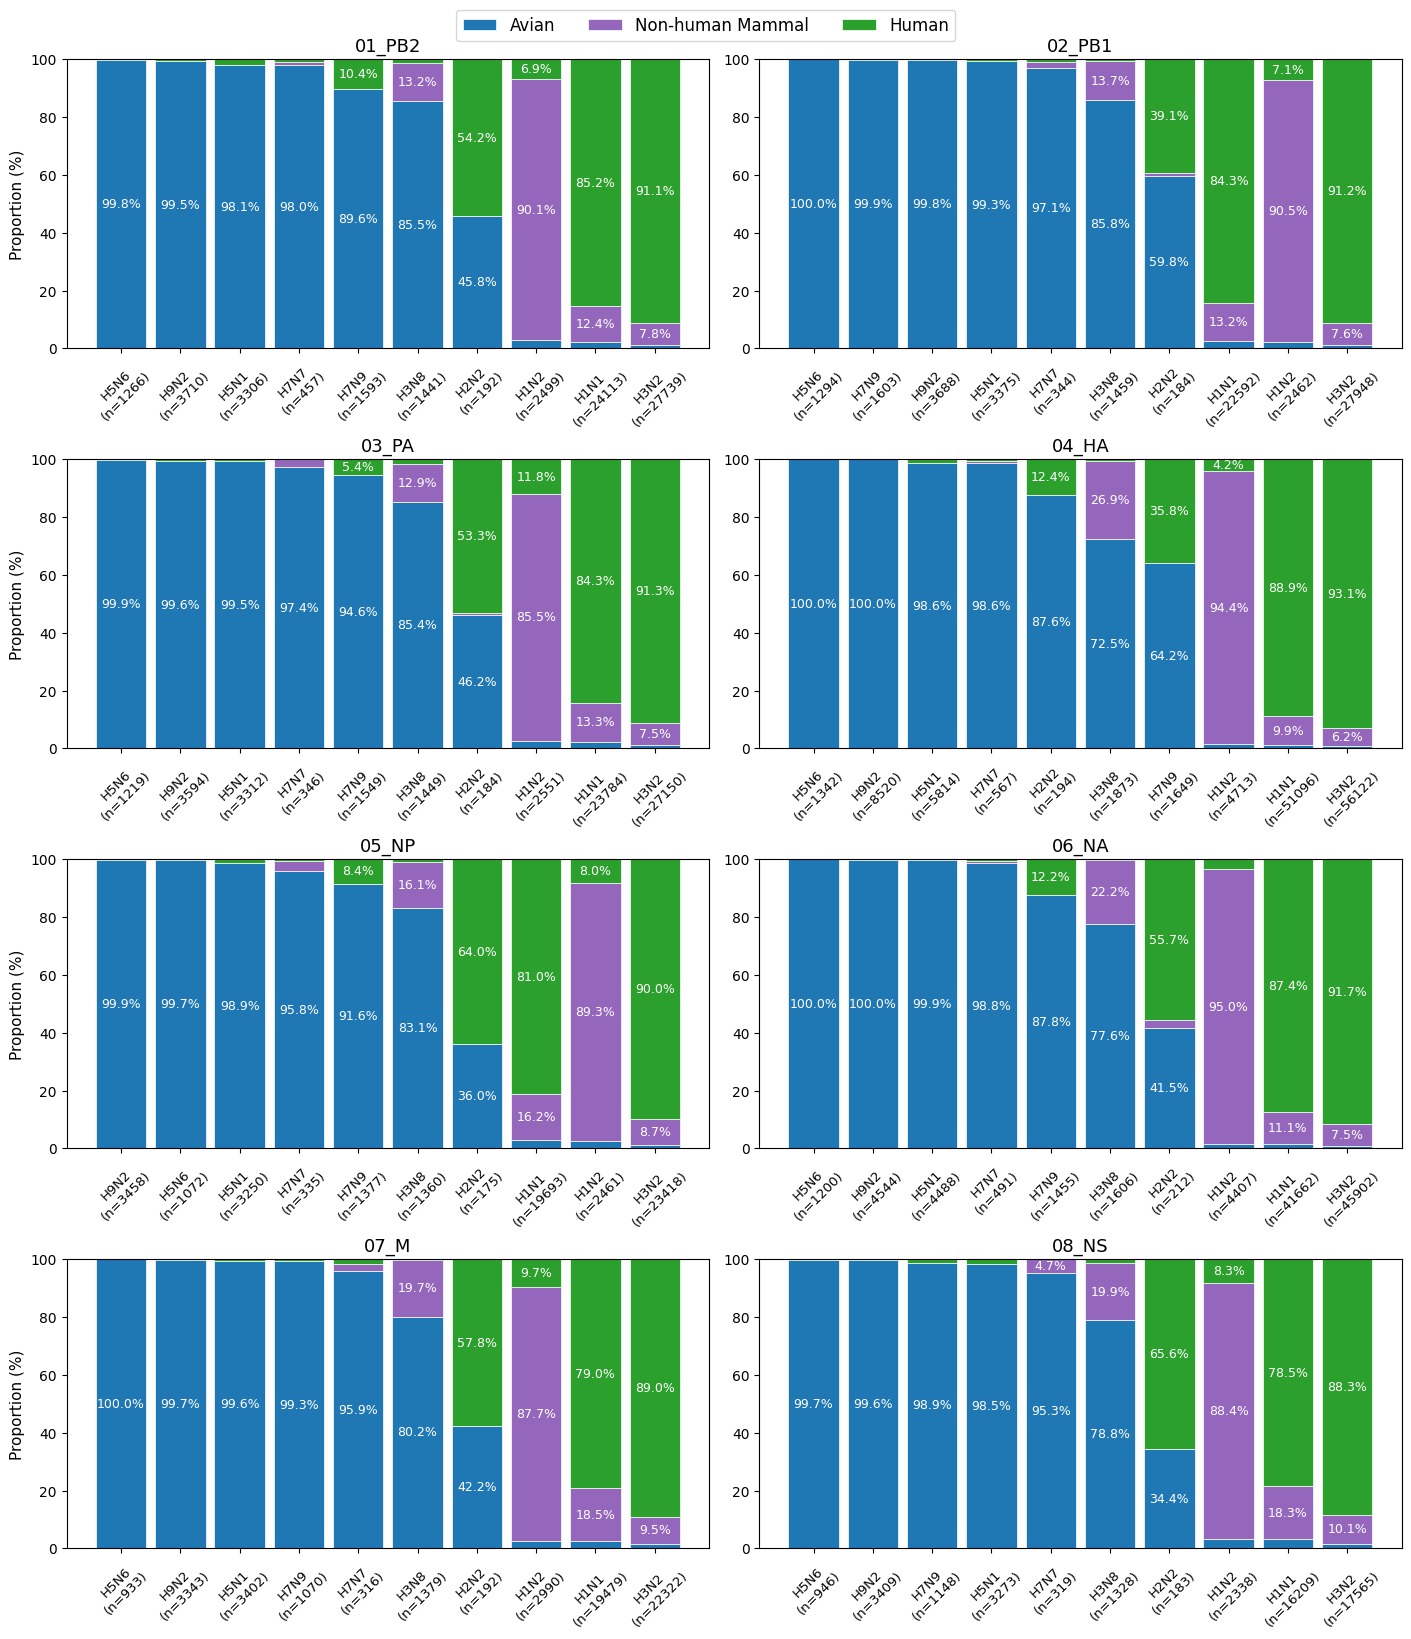

In [4]:
print(f"{'='*60}")
print("STARTING ANALYSIS (3-Class)")
print(f"{'='*60}")
all_segment_dfs = {}
for seg in segments:
    print(f"\nProcessing Segment: {seg}...")
    combined_dfs = []

    # --- Load Pre-2020 ---
    csv_pre = os.path.join(base_meta_path, f"{seg}", f"{seg}_Train_Filtered.csv")
    npy_pre = os.path.join(pre2020_pred_path, f"{seg}_preds_cal_fold_0.npy") #pre2020 has no fold
    if os.path.exists(csv_pre) and os.path.exists(npy_pre):
        try:
            df_pre = pd.read_csv(csv_pre)
            df_pre = df_pre[df_cols]
            preds_pre = np.load(npy_pre)
            # H7N7_equine_index = df_pre[df_pre['Isolate_Name']=='A/equine/Prague/1956'].index
            # print ('H7N7 Equine predicion', preds_pre[H7N7_equine_index])
            if preds_pre.ndim > 1: preds_pre = preds_pre.ravel()
            if len(df_pre) == len(preds_pre):
                df_pre['pred_label'] = preds_pre.astype(int)
                combined_dfs.append(df_pre)
        except: pass

    # --- Load Post-2020 ---
    csv_post = os.path.join(base_meta_path, f"{seg}", f"Part1_2_{seg}_Test_Filtered.csv")
    if os.path.exists(csv_post):
        try:
            df_post = pd.read_csv(csv_post)
            df_post = df_post[df_cols]
            fold_preds = []
            for i in range(num_folds):
                npy_post = os.path.join(post2020_pred_path, f"{seg}_preds_cal_fold_{i}.npy")
                if os.path.exists(npy_post):
                    arr = np.load(npy_post)
                    if arr.ndim > 1: arr = arr.ravel()
                    if len(arr) == len(df_post): fold_preds.append(arr.astype(int))
            if fold_preds:
                maj_vote, _ = mode(np.vstack(fold_preds), axis=0, keepdims=False)
                df_post['pred_label'] = maj_vote[0] if isinstance(maj_vote, tuple) else maj_vote # vote majority for 10 folds
                combined_dfs.append(df_post)
        except: pass

    # --- Merge & Run ---
    if len(combined_dfs) > 0:
        
        full_df = pd.concat(combined_dfs, ignore_index=True)
        f1 = f1_score(full_df[ground_truth_col], full_df['pred_label'], average='macro')
        print(f"  [Metrics] F1: {f1:.4f} | Samples: {len(full_df)}")

        all_segment_dfs[seg] = full_df

plot_grid_spectrum(all_segment_dfs, target_subtypes, label_map)

print(f"\n{'='*60}\nDone.")
